<a href="https://colab.research.google.com/github/Buddhiimz/DeepLearning_Project/blob/feature%2Fbuddhima/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Orchid Classification - Custom CNN
# Dataset: Orchid Flower Dataset (52 classes, 3559 images)

# Install required packages
!pip install split-folders

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import splitfolders

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Set path to your dataset
# Replace this with your actual path in Google Drive
dataset_path = '/content/drive/MyDrive/DL Project'  # Adjust this path!

# Check if path exists
if os.path.exists(dataset_path):
    print(f"✓ Dataset found at {dataset_path}")
    print(f"Contents: {os.listdir(dataset_path)[:10]}")  # Show first 10 items
else:
    print("✗ Dataset not found! Please update the path.")

✓ Dataset found at /content/drive/MyDrive/DL Project
Contents: ['Splits', '.ipynb_checkpoints', 'Flowers test', 'Flowers train']


In [5]:
# Since Kaggle dataset has train and test folders,
# we need to split TRAIN into train + validation

# Define paths - UPDATE THESE PATHS!
original_train = '/content/drive/MyDrive/DL Project/Flowers train'  # Your train folder
original_test = '/content/drive/MyDrive/DL Project/Flowers test'    # Your test folder
output_path = '/content/drive/MyDrive/DL Project/Splits'     # Output folder

# Split train folder into train (80%) and validation (20%)
print("Splitting training data into train and validation sets...")
splitfolders.ratio(original_train, output=output_path,
                   seed=42, ratio=(.8, .2), group_prefix=None)

print("Dataset split complete!")

# The splitfolders creates 'train' and 'val' folders
# We need to manually copy the test folder
import shutil

# Copy test folder to output path
test_output = os.path.join(output_path, 'test')
if not os.path.exists(test_output):
    shutil.copytree(original_test, test_output)
    print("Test folder copied!")

# Final paths
train_dir = os.path.join(output_path, 'train')
val_dir = os.path.join(output_path, 'val')
test_dir = os.path.join(output_path, 'test')

print(f" ✓ Final structure:")
print(f"  Train: {train_dir}")
print(f"  Val: {val_dir}")
print(f"  Test: {test_dir}")

Splitting training data into train and validation sets...


Copying files: 2834 files [10:07,  4.66 files/s]

Dataset split complete!
 ✓ Final structure:
  Train: /content/drive/MyDrive/DL Project/Splits/train
  Val: /content/drive/MyDrive/DL Project/Splits/val
  Test: /content/drive/MyDrive/DL Project/Splits/test


Number of classes: 52
First 10 classes: ['n0034', 'n0050', 'n0036', 'n0043', 'n0037', 'n0048', 'n0038', 'n0032', 'n0040', 'n0033']
 Total training images: 2702
 Class distribution statistics:
count     52.000000
mean      51.961538
std       31.384998
min       15.000000
25%       26.000000
50%       48.000000
75%       65.000000
max      161.000000
Name: Image_Count, dtype: float64


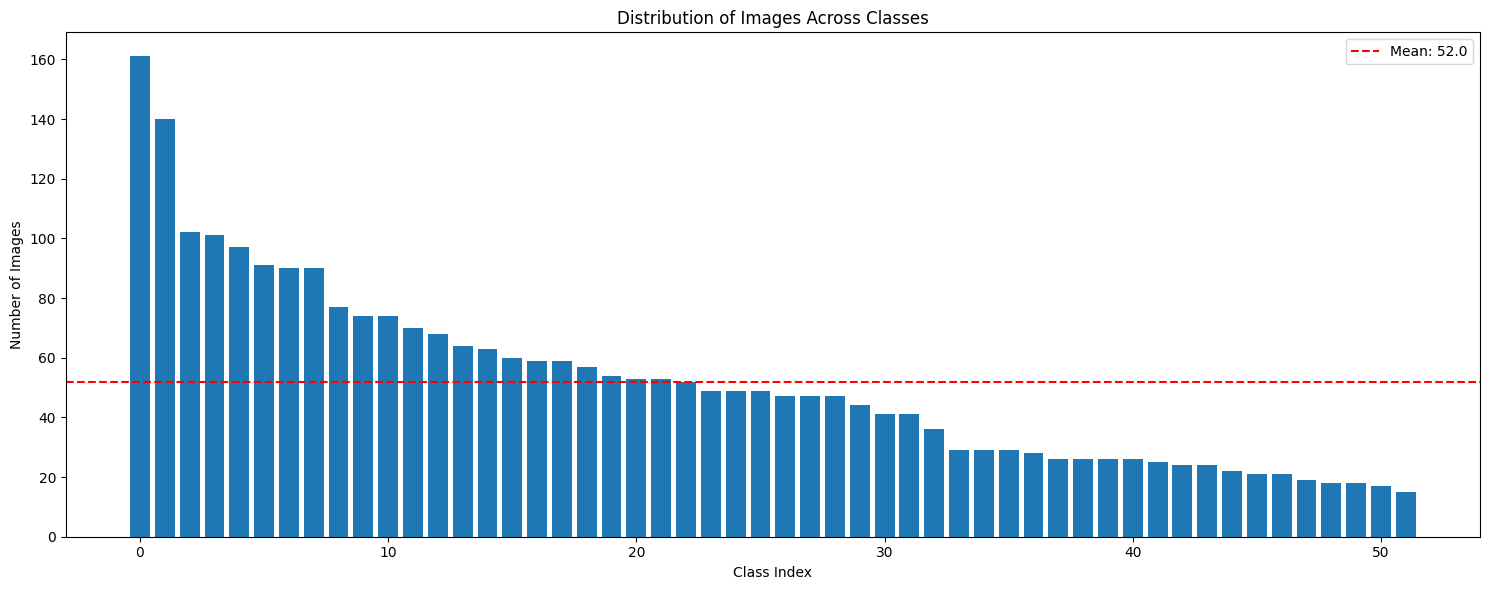

In [6]:
# Exploratory Data Analysis

# Count classes and images
classes = os.listdir(train_dir)
num_classes = len(classes)
print(f"Number of classes: {num_classes}")
print(f"First 10 classes: {classes[:10]}")

# Count images per class
image_counts = {}
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    num_images = len(os.listdir(class_path))
    image_counts[class_name] = num_images

# Create dataframe
df = pd.DataFrame(list(image_counts.items()),
                  columns=['Class', 'Image_Count'])
df = df.sort_values('Image_Count', ascending=False)

print(f" Total training images: {df['Image_Count'].sum()}")
print(f" Class distribution statistics:")
print(df['Image_Count'].describe())

# Visualize class distribution
plt.figure(figsize=(15, 6))
plt.bar(range(len(df)), df['Image_Count'])
plt.xlabel('Class Index')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Classes')
plt.axhline(y=df['Image_Count'].mean(), color='r',
            linestyle='--', label=f'Mean: {df["Image_Count"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()